In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

data_path = "Data"

files = [
    "data_1.xlsx",
    "data_2.xlsx",
    "data_3.xlsx",
    "data_4.xlsx",
    "HEROdata2.xlsx"
]

dataframes = {}

for file in files:
    path = os.path.join(data_path, file)
    dataframes[file] = pd.read_excel(path)
    print(f"{file}: {dataframes[file].shape}")

data_1.xlsx: (69, 51)
data_2.xlsx: (194, 51)
data_3.xlsx: (183, 51)
data_4.xlsx: (183, 51)
HEROdata2.xlsx: (907, 51)


In [3]:
full = pd.concat(dataframes.values(), ignore_index=True)

print("Combined shape:", full.shape)
print("\nColumns:")
print(full.columns.tolist())

print("\nLabel counts:")
print(full["Label"].value_counts())

Combined shape: (1536, 51)

Columns:
['Number of ports', 'Number of nets', 'Number of cells', 'Number of combinational cells', 'Number of sequential cells', 'Number of macros/black boxes', 'Number of buf/inv', 'Number of references', 'Combinational area', 'Buf/Inv area', 'Noncombinational area', 'Macro/Black Box area', 'Total cell area', 'Cell Internal Power (mW)', 'Net Switching Power (mW)', 'Total Dynamic Power (mW)', 'Cell Leakage Power (mW)', 'IO_Pad Internal Power', 'IO_Pad Switching Power', 'IO_Pad Leakage Power', 'IO_Pad Total Power', 'Memory Internal Power', 'Memory Switching Power', 'Memory Leakage Power', 'Memory Total Power', 'Black_Box Internal Power', 'Black_Box Switching Power', 'Black_Box Leakage Power', 'Black_Box Total Power', 'Clock_Network Internal Power', 'Clock_Network Switching Power', 'Clock_Network Leakage Power', 'Clock_Network Total Power', 'Register Internal Power', 'Register Switching Power', 'Register Leakage Power', 'Register Total Power', 'Sequential Inte

In [4]:
# Remove extra quotes from text columns
full["Label"] = full["Label"].astype(str).str.strip("'\" ")
full["Circuit"] = full["Circuit"].astype(str).str.strip("'\" ")

# Remove duplicate rows
before = len(full)
full = full.drop_duplicates().reset_index(drop=True)
after = len(full)

print("Rows before:", before)
print("Rows after :", after)
print("Duplicates removed:", before - after)

print("\nLabel counts:")
print(full["Label"].value_counts())

Rows before: 1536
Rows after : 903
Duplicates removed: 633

Label counts:
Label
Trojan Infected    885
Trojan Free         18
Name: count, dtype: int64


In [5]:
# Check missing values
missing = full.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Sequential Internal Power    1
Sequential Total Power       1
dtype: int64


In [6]:
# Fill missing numeric values with their column median
full["Sequential Internal Power"] = full["Sequential Internal Power"].fillna(
    full["Sequential Internal Power"].median()
)

full["Sequential Total Power"] = full["Sequential Total Power"].fillna(
    full["Sequential Total Power"].median()
)

print("Remaining missing values:", full.isnull().sum().sum())

Remaining missing values: 0


In [7]:
# 49 numerical hardware features
feature_cols = full.select_dtypes(include=np.number).columns.tolist()

# Target and circuit identifier
X = full[feature_cols]
y = full["Label"]
circuits = full["Circuit"]

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 49
X shape: (903, 49)
y shape: (903,)


In [8]:
full["Family"] = full["Circuit"].str.replace(
    r"-T\d+$", "", regex=True
).str.upper()

print("Number of families:", full["Family"].nunique())

print("\nFamilies:")
print(sorted(full["Family"].unique()))

Number of families: 18

Families:
['AES', 'B15', 'C2670', 'C3540', 'C5315', 'C6288', 'ETHERNETMAC10GE', 'MEMCTRL', 'PIC16F84', 'RS232', 'S13207', 'S1423', 'S15850', 'S35932', 'S38417', 'S38584', 'VGA_LCD', 'WB_CONMAX']


In [9]:
clean_families = (
    full[full["Label"] == "Trojan Free"]["Family"]
    .value_counts()
    .sort_index()
)

print("Clean circuits per family:")
print(clean_families)

print("\nFamilies without a clean baseline:")
all_families = set(full["Family"].unique())
clean_family_set = set(clean_families.index)

print(sorted(all_families - clean_family_set))

Clean circuits per family:
Family
AES                1
B15                1
C2670              1
C3540              1
C5315              1
C6288              1
ETHERNETMAC10GE    1
MEMCTRL            1
S13207             1
S1423              1
S15850             2
S35932             2
S38417             1
S38584             1
VGA_LCD            1
WB_CONMAX          1
Name: count, dtype: int64

Families without a clean baseline:
['PIC16F84', 'RS232']


In [10]:
# Families that have at least one known clean circuit
valid_families = clean_family_set

full_valid = full[full["Family"].isin(valid_families)].copy()

print("Original rows:", len(full))
print("Rows after removing families without baseline:", len(full_valid))

print("\nLabels:")
print(full_valid["Label"].value_counts())

print("\nFamilies:")
print(full_valid["Family"].nunique())

Original rows: 903
Rows after removing families without baseline: 880

Labels:
Label
Trojan Infected    862
Trojan Free         18
Name: count, dtype: int64

Families:
16


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(full_valid, full_valid["Label"]), 1
):

    train = full_valid.iloc[train_idx].copy()
    test = full_valid.iloc[test_idx].copy()

    # Clean baselines from TRAINING DATA ONLY
    baselines = (
        train[train["Label"] == "Trojan Free"]
        .groupby("Family")[feature_cols]
        .mean()
    )

    # Test rows whose family has a training clean baseline
    test = test[test["Family"].isin(baselines.index)].copy()

    # Training rows whose family has a training clean baseline
    train = train[train["Family"].isin(baselines.index)].copy()

    # Create baseline values for every row
    train_baseline = pd.DataFrame(
        [baselines.loc[f] for f in train["Family"]],
        index=train.index,
        columns=feature_cols
    )

    test_baseline = pd.DataFrame(
        [baselines.loc[f] for f in test["Family"]],
        index=test.index,
        columns=feature_cols
    )

    # Avoid division by zero
    train_base_safe = train_baseline.replace(0, np.nan)
    test_base_safe = test_baseline.replace(0, np.nan)

    # Baseline-normalized features
    X_train = (
        (train[feature_cols] - train_baseline) /
        train_base_safe
    ).fillna(0)

    X_test = (
        (test[feature_cols] - test_baseline) /
        test_base_safe
    ).fillna(0)

    y_train = (train["Label"] == "Trojan Infected").astype(int)
    y_test = (test["Label"] == "Trojan Infected").astype(int)

    # Random Forest
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(predictions)

    print(
        f"Fold {fold}: "
        f"Train={len(train)}, Test={len(test)}, "
        f"Baselines={len(baselines)}"
    )


# ===== FINAL RESULTS =====

accuracy = accuracy_score(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)

cm = confusion_matrix(y_true_all, y_pred_all)

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\n===== FINAL RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"FPR      : {fpr:.4f}")
print(f"FNR      : {fnr:.4f}")

print("\nConfusion Matrix:")
print(cm)

Fold 1: Train=685, Test=169, Baselines=14
Fold 2: Train=468, Test=104, Baselines=12
Fold 3: Train=608, Test=156, Baselines=14
Fold 4: Train=511, Test=120, Baselines=13
Fold 5: Train=700, Test=172, Baselines=13

===== FINAL RESULTS =====
Accuracy : 0.9931
Precision: 0.9944
Recall   : 0.9986
F1-score : 0.9965
FPR      : 1.0000
FNR      : 0.0014

Confusion Matrix:
[[  0   4]
 [  1 716]]


In [15]:
from sklearn.model_selection import StratifiedKFold

# Separate trusted clean reference circuits and infected circuits
clean_data = full_valid[full_valid["Label"] == "Trojan Free"].copy()
infected_data = full_valid[full_valid["Label"] == "Trojan Infected"].copy()

# Clean baselines = trusted reference
baselines = (
    clean_data
    .groupby("Family")[feature_cols]
    .mean()
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(infected_data, infected_data["Family"]), 1
):

    train_infected = infected_data.iloc[train_idx].copy()
    test_infected = infected_data.iloc[test_idx].copy()

    # Training data = clean references + infected training samples
    train = pd.concat([clean_data, train_infected])

    # Normalize training data
    train_baseline = pd.DataFrame(
        [baselines.loc[f] for f in train["Family"]],
        index=train.index,
        columns=feature_cols
    )

    # Normalize test data
    test_baseline = pd.DataFrame(
        [baselines.loc[f] for f in test_infected["Family"]],
        index=test_infected.index,
        columns=feature_cols
    )

    train_safe = train_baseline.replace(0, np.nan)
    test_safe = test_baseline.replace(0, np.nan)

    X_train = (
        (train[feature_cols] - train_baseline) / train_safe
    ).fillna(0)

    X_test = (
        (test_infected[feature_cols] - test_baseline) / test_safe
    ).fillna(0)

    y_train = (train["Label"] == "Trojan Infected").astype(int)
    y_test = np.ones(len(test_infected), dtype=int)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(predictions)

    print(
        f"Fold {fold}: "
        f"Train infected={len(train_infected)}, "
        f"Test infected={len(test_infected)}"
    )

C:\Users\Chidanand B\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: Train infected=689, Test infected=173
Fold 2: Train infected=689, Test infected=173
Fold 3: Train infected=690, Test infected=172
Fold 4: Train infected=690, Test infected=172
Fold 5: Train infected=690, Test infected=172


In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

X = full_valid[feature_cols]
y = (full_valid["Label"] == "Trojan Infected").astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true = []
y_pred = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    y_true.extend(y_test)
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print("===== RAW FEATURE RANDOM FOREST =====")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
print(f"FPR      : {fp/(fp+tn):.4f}")
print(f"FNR      : {fn/(fn+tp):.4f}")

print("\nConfusion Matrix:")
print(cm)

===== RAW FEATURE RANDOM FOREST =====
Accuracy : 0.9716
Precision: 0.9805
Recall   : 0.9907
F1-score : 0.9856
FPR      : 0.9444
FNR      : 0.0093

Confusion Matrix:
[[  1  17]
 [  8 854]]


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

clean_data = full_valid[full_valid["Label"] == "Trojan Free"].copy()
infected_data = full_valid[full_valid["Label"] == "Trojan Infected"].copy()

baselines = (
    clean_data
    .groupby("Family")[feature_cols]
    .mean()
)

# Use all usable rows
data = full_valid.copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true = []
y_prob = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(data, data["Label"]), 1
):

    train = data.iloc[train_idx].copy()
    test = data.iloc[test_idx].copy()

    # Training-fold baselines only
    fold_baselines = (
        train[train["Label"] == "Trojan Free"]
        .groupby("Family")[feature_cols]
        .mean()
    )

    # Only evaluate test rows with an available training baseline
    test = test[test["Family"].isin(fold_baselines.index)]

    train = train[train["Family"].isin(fold_baselines.index)]

    train_baseline = pd.DataFrame(
        [fold_baselines.loc[f] for f in train["Family"]],
        index=train.index,
        columns=feature_cols
    )

    test_baseline = pd.DataFrame(
        [fold_baselines.loc[f] for f in test["Family"]],
        index=test.index,
        columns=feature_cols
    )

    train_safe = train_baseline.replace(0, np.nan)
    test_safe = test_baseline.replace(0, np.nan)

    X_train = (
        (train[feature_cols] - train_baseline) /
        train_safe
    ).fillna(0)

    X_test = (
        (test[feature_cols] - test_baseline) /
        test_safe
    ).fillna(0)

    y_train = (train["Label"] == "Trojan Infected").astype(int)
    y_test = (test["Label"] == "Trojan Infected").astype(int)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    y_true.extend(y_test)
    y_prob.extend(probabilities)

print("Out-of-fold predictions generated.")
print("Samples evaluated:", len(y_true))

Out-of-fold predictions generated.
Samples evaluated: 721


In [18]:
thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:

    predictions = (np.array(y_prob) >= threshold).astype(int)

    cm = confusion_matrix(y_true, predictions)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"FPR      : {fpr:.4f}")
    print("Confusion Matrix:")
    print(cm)


Threshold: 0.5
Accuracy : 0.9931
Precision: 0.9944
Recall   : 0.9986
FPR      : 1.0000
Confusion Matrix:
[[  0   4]
 [  1 716]]

Threshold: 0.6
Accuracy : 0.9917
Precision: 0.9944
Recall   : 0.9972
FPR      : 1.0000
Confusion Matrix:
[[  0   4]
 [  2 715]]

Threshold: 0.7
Accuracy : 0.9917
Precision: 0.9958
Recall   : 0.9958
FPR      : 0.7500
Confusion Matrix:
[[  1   3]
 [  3 714]]

Threshold: 0.8
Accuracy : 0.9889
Precision: 0.9958
Recall   : 0.9930
FPR      : 0.7500
Confusion Matrix:
[[  1   3]
 [  5 712]]

Threshold: 0.9
Accuracy : 0.9792
Precision: 0.9972
Recall   : 0.9819
FPR      : 0.5000
Confusion Matrix:
[[  2   2]
 [ 13 704]]


In [19]:
# Final evaluation at threshold = 0.7

threshold = 0.70

final_predictions = (np.array(y_prob) >= threshold).astype(int)

cm = confusion_matrix(y_true, final_predictions)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, final_predictions)
precision = precision_score(y_true, final_predictions)
recall = recall_score(y_true, final_predictions)
f1 = f1_score(y_true, final_predictions)

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("===== FINAL RANDOM FOREST RESULTS =====")
print(f"Threshold : {threshold}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"FPR       : {fpr:.4f}")
print(f"FNR       : {fnr:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

===== FINAL RANDOM FOREST RESULTS =====
Threshold : 0.7
Accuracy  : 0.9917
Precision : 0.9958
Recall    : 0.9958
F1-score  : 0.9958
FPR       : 0.7500
FNR       : 0.0042

Confusion Matrix:
[[  1   3]
 [  3 714]]

TN: 1
FP: 3
FN: 3
TP: 714


Top 15 important features:
                          Feature  Importance
7            Number of references    0.222767
15       Total Dynamic Power (mW)    0.110982
2                 Number of cells    0.105782
42  Combinational Switching Power    0.092095
44      Combinational Total Power    0.089130
1                  Number of nets    0.084175
14       Net Switching Power (mW)    0.072424
48              Total Total Power    0.069921
4      Number of sequential cells    0.065441
46          Total Switching Power    0.062118
0                 Number of ports    0.016079
34       Register Switching Power    0.001393
13       Cell Internal Power (mW)    0.001179
41   Combinational Internal Power    0.001109
45           Total Internal Power    0.000782


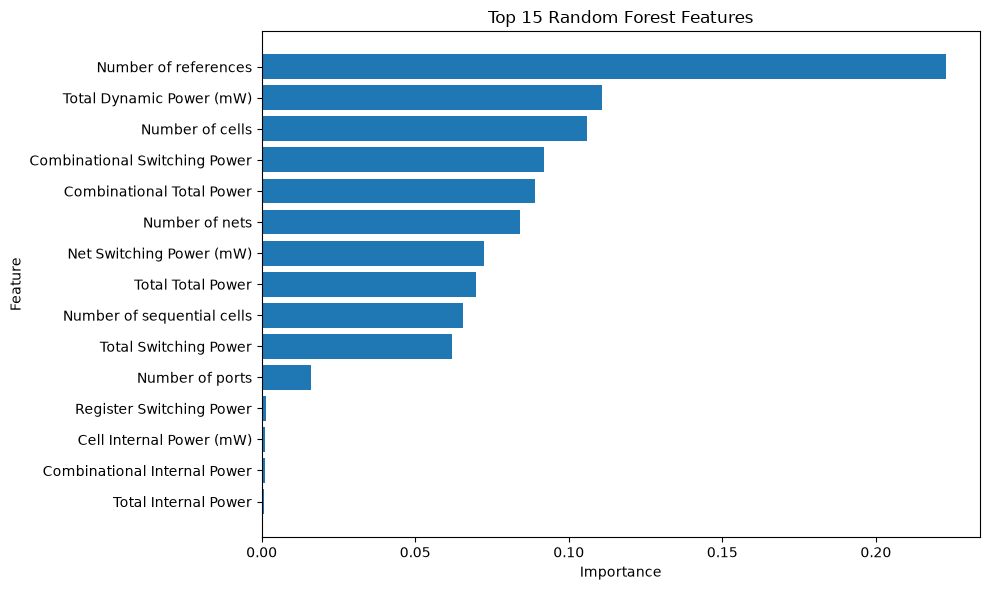

In [20]:
import matplotlib.pyplot as plt

# Train final Random Forest on the available normalized data
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

# Feature importance
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 15 important features:")
print(importance.head(15))

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(
    importance["Feature"].head(15)[::-1],
    importance["Importance"].head(15)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")
plt.tight_layout()
plt.show()

In [21]:
import joblib

# Clean reference baselines from the complete dataset
final_baselines = (
    full_valid[full_valid["Label"] == "Trojan Free"]
    .groupby("Family")[feature_cols]
    .mean()
)

# Create normalized dataset
baseline_values = pd.DataFrame(
    [final_baselines.loc[f] for f in full_valid["Family"]],
    index=full_valid.index,
    columns=feature_cols
)

safe_baseline = baseline_values.replace(0, np.nan)

X_final = (
    (full_valid[feature_cols] - baseline_values) /
    safe_baseline
).fillna(0)

y_final = (full_valid["Label"] == "Trojan Infected").astype(int)

# Final Random Forest
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

final_model.fit(X_final, y_final)

# Save model and baselines
joblib.dump(final_model, "hardware_trojan_rf.pkl")
joblib.dump(final_baselines, "clean_baselines.pkl")

print("Final model trained successfully.")
print("Saved:")
print("- hardware_trojan_rf.pkl")
print("- clean_baselines.pkl")

Final model trained successfully.
Saved:
- hardware_trojan_rf.pkl
- clean_baselines.pkl


In [22]:
def predict_trojan(circuit_data, family):
    baseline = final_baselines.loc[family]

    normalized = (
        (circuit_data[feature_cols] - baseline) /
        baseline.replace(0, np.nan)
    ).fillna(0)

    probability = final_model.predict_proba(
        normalized.to_frame().T
    )[0, 1]

    threshold = 0.70

    prediction = (
        "Trojan Infected"
        if probability >= threshold
        else "Trojan Free"
    )

    return prediction, probability


print("Prediction function ready.")

Prediction function ready.


In [23]:
# Test on the first circuit in our dataset

test_circuit = full_valid.iloc[0]

prediction, probability = predict_trojan(
    test_circuit,
    test_circuit["Family"]
)

print("Circuit :", test_circuit["Circuit"])
print("Actual  :", test_circuit["Label"])
print("Predicted:", prediction)
print(f"Probability: {probability:.4f}")

Circuit : S38417
Actual  : Trojan Free
Predicted: Trojan Free
Probability: 0.0000


In [24]:
# Find the first known Trojan-infected circuit
trojan_circuit = full_valid[
    full_valid["Label"] == "Trojan Infected"
].iloc[0]

prediction, probability = predict_trojan(
    trojan_circuit,
    trojan_circuit["Family"]
)

print("Circuit :", trojan_circuit["Circuit"])
print("Actual  :", trojan_circuit["Label"])
print("Predicted:", prediction)
print(f"Probability: {probability:.4f}")

Circuit : S38417-T100
Actual  : Trojan Infected
Predicted: Trojan Infected
Probability: 0.9933


In [25]:
def predict_file(file_path):
    # Read input file
    if file_path.lower().endswith(".csv"):
        data = pd.read_csv(file_path)
    elif file_path.lower().endswith(".xlsx"):
        data = pd.read_excel(file_path)
    else:
        raise ValueError("Use a .csv or .xlsx file")

    results = []

    for _, row in data.iterrows():

        family = str(row["Circuit"]).replace("'", "").upper()
        family = pd.Series([family]).str.replace(
            r"-T\d+$", "", regex=True
        ).iloc[0]

        if family not in final_baselines.index:
            results.append({
                "Circuit": row["Circuit"],
                "Prediction": "No baseline available",
                "Trojan Probability": None
            })
            continue

        prediction, probability = predict_trojan(
            row,
            family
        )

        results.append({
            "Circuit": row["Circuit"],
            "Prediction": prediction,
            "Trojan Probability": round(probability, 4)
        })

    return pd.DataFrame(results)


print("File prediction system ready.")

File prediction system ready.


In [26]:
result = predict_file("Data/data_1.xlsx")

print(result.head(10))

         Circuit       Prediction  Trojan Probability
0       'S38417'      Trojan Free              0.0000
1  'S38417-T100'  Trojan Infected              0.9933
2  'S38417-T200'  Trojan Infected              0.9933
3  'S38417-T300'  Trojan Infected              1.0000
4       'S35932'      Trojan Free              0.0000
5  'S35932-T100'  Trojan Infected              0.7467
6  'S35932-T200'  Trojan Infected              0.7567
7  'S35932-T300'  Trojan Infected              0.8767
8       'S35932'      Trojan Free              0.0000
9  'S35932-T400'  Trojan Infected              0.9867


In [27]:
all_results = []

for file in files:
    path = os.path.join(data_path, file)

    result = predict_file(path)
    result["Source File"] = file

    all_results.append(result)

complete_results = pd.concat(all_results, ignore_index=True)

print("Total predictions:", len(complete_results))
print("\nPrediction counts:")
print(complete_results["Prediction"].value_counts())

print("\nFirst 20 predictions:")
print(complete_results.head(20))

Total predictions: 1536

Prediction counts:
Prediction
Trojan Infected          1465
Trojan Free                48
No baseline available      23
Name: count, dtype: int64

First 20 predictions:
          Circuit       Prediction  Trojan Probability  Source File
0        'S38417'      Trojan Free              0.0000  data_1.xlsx
1   'S38417-T100'  Trojan Infected              0.9933  data_1.xlsx
2   'S38417-T200'  Trojan Infected              0.9933  data_1.xlsx
3   'S38417-T300'  Trojan Infected              1.0000  data_1.xlsx
4        'S35932'      Trojan Free              0.0000  data_1.xlsx
5   'S35932-T100'  Trojan Infected              0.7467  data_1.xlsx
6   'S35932-T200'  Trojan Infected              0.7567  data_1.xlsx
7   'S35932-T300'  Trojan Infected              0.8767  data_1.xlsx
8        'S35932'      Trojan Free              0.0000  data_1.xlsx
9   'S35932-T400'  Trojan Infected              0.9867  data_1.xlsx
10  'S35932-T401'  Trojan Infected              1.0000  da

In [28]:
# Predict only on the cleaned, unique dataset
final_results = []

for _, row in full_valid.iterrows():

    prediction, probability = predict_trojan(
        row,
        row["Family"]
    )

    final_results.append({
        "Circuit": row["Circuit"],
        "Actual Label": row["Label"],
        "Predicted": prediction,
        "Trojan Probability": probability
    })

final_results = pd.DataFrame(final_results)

# Save results
final_results.to_excel(
    "final_trojan_predictions.xlsx",
    index=False
)

final_results.to_csv(
    "final_trojan_predictions.csv",
    index=False
)

print("Saved successfully.")
print("Rows:", len(final_results))
print("\nPrediction counts:")
print(final_results["Predicted"].value_counts())

Saved successfully.
Rows: 880

Prediction counts:
Predicted
Trojan Infected    862
Trojan Free         18
Name: count, dtype: int64
